In [1]:
import requests
import pandas as pd
import numpy as np

def fetch_binance_agg_trades(symbol="SOLUSDT", limit=1000):
    """Fetch public high-frequency aggregated trade data from Binance"""
    print(f"Fetching the latest {limit} tick data points for {symbol} from Binance...")
    url = f"https://api.binance.com/api/v3/aggTrades?symbol={symbol}&limit={limit}"
    response = requests.get(url)
    data = response.json()
    
    df = pd.DataFrame(data)
    # Rename columns to follow AFML conventions
    df = df.rename(columns={
        'p': 'price',
        'q': 'quantity',
        'T': 'timestamp',
        'm': 'is_buyer_maker'
    })
    
    df['price'] = df['price'].astype(float)
    df['quantity'] = df['quantity'].astype(float)
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    
    # Compute the absolute dollar value of each trade (Price * Volume)
    df['dollar_value'] = df['price'] * df['quantity']
    return df

def generate_dollar_bars(tick_df, dollar_threshold=500000):
    """
    Implement AFML Information-Driven Bars: Dollar Bars
    and simultaneously compute the micro order flow imbalance (OFI)
    """
    print(f"Compressing tick data into Dollar Bars (threshold: {dollar_threshold} USD)...")
    
    bars = []
    # Initialize the current bar's micro-state
    current_bar = {
        'open': None, 'high': -np.inf, 'low': np.inf, 'close': None,
        'volume': 0, 'dollar_value': 0, 'net_aggressive_buy': 0
    }
    
    for _, row in tick_df.iterrows():
        # Record the opening price and timestamp
        if current_bar['open'] is None:
            current_bar['open'] = row['price']
            current_bar['timestamp'] = row['timestamp']
            
        # Update high, low, close, and cumulative volume
        current_bar['high'] = max(current_bar['high'], row['price'])
        current_bar['low'] = min(current_bar['low'], row['price'])
        current_bar['close'] = row['price']
        current_bar['volume'] += row['quantity']
        current_bar['dollar_value'] += row['dollar_value']
        
        # Core: compute net aggressive buy/sell (OFI)
        # If is_buyer_maker is False, the maker is the seller and the taker is the buyer (aggressive buy)
        if not row['is_buyer_maker']:
            current_bar['net_aggressive_buy'] += row['dollar_value']
        else:
            current_bar['net_aggressive_buy'] -= row['dollar_value']
            
        # When cumulative dollar value exceeds the threshold, sample a new bar
        if current_bar['dollar_value'] >= dollar_threshold:
            bars.append(current_bar)
            # Reset state for the next bar
            current_bar = {
                'open': None, 'high': -np.inf, 'low': np.inf, 'close': None,
                'volume': 0, 'dollar_value': 0, 'net_aggressive_buy': 0
            }
            
    bars_df = pd.DataFrame(bars)
    if not bars_df.empty:
        bars_df = bars_df.set_index('timestamp')
    return bars_df

# Execute test: fetch SOL/USDT data and convert
tick_data = fetch_binance_agg_trades(symbol="SOLUSDT", limit=5000)
dollar_bars = generate_dollar_bars(tick_data, dollar_threshold=100000)

print("\n=== Microstructure Reconstruction Complete: SOL/USDT Dollar Bars and Order Flow ===")
print(dollar_bars[['close', 'dollar_value', 'net_aggressive_buy']].tail())


Fetching the latest 5000 tick data points for SOLUSDT from Binance...
Compressing tick data into Dollar Bars (threshold: 100000 USD)...

=== Microstructure Reconstruction Complete: SOL/USDT Dollar Bars and Order Flow ===
                          close  dollar_value  net_aggressive_buy
timestamp                                                        
2026-09-24 09:46:10.842  113.21  102773.33555        -37094.88241
2026-09-24 09:46:50.465  113.20  100716.95443         -7859.80507
2026-09-24 09:47:16.343  113.25  102436.01501         35173.90183
2026-09-24 09:47:40.445  113.25  100490.00409          3455.62749
2026-09-24 09:48:02.959  113.18  101254.84162        -57751.13848


In [2]:
import scipy.stats as stats

# Assume tick_data and dollar_bars have been generated in the previous code block
# 1. Generate traditional time-based bars (1-minute Time Bars) as the control group
tick_data_idx = tick_data.set_index('timestamp')
time_bars = tick_data_idx.resample('1min').agg({'price': 'last'}).dropna()

# 2. Compute continuous log returns for both
time_returns = np.log(time_bars['price'] / time_bars['price'].shift(1)).dropna()
dollar_returns = np.log(dollar_bars['close'] / dollar_bars['close'].shift(1)).dropna()

# 3. Kurtosis and Jarque-Bera normality test
def print_stats(name, returns):
    kurtosis = stats.kurtosis(returns)
    jb_stat, jb_p_value = stats.jarque_bera(returns)
    print(f"[{name}]")
    print(f"Kurtosis: {kurtosis:.4f} (normal distribution baseline is 0)")
    print(f"JB test p-value: {jb_p_value:.4e}\n")

print("=== Return Microstructure Normality Comparison ===")
print_stats("Traditional 1-minute Time Bars", time_returns)
print_stats("AFML Dollar Bars", dollar_returns)


=== Return Microstructure Normality Comparison ===
[Traditional 1-minute Time Bars]
Kurtosis: -1.2651 (normal distribution baseline is 0)
JB test p-value: 7.8046e-01

[AFML Dollar Bars]
Kurtosis: -0.7144 (normal distribution baseline is 0)
JB test p-value: 8.7309e-01



In [3]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# 1. Generate fractionally differenced decay weights (AFML standard implementation)
def get_weights_ffd(d, thres=1e-5):
    w, k = [1.], 1
    while True:
        w_ = -w[-1] / k * (d - k + 1)
        if abs(w_) < thres:
            break
        w.append(w_)
        k += 1
    return np.array(w[::-1]).reshape(-1, 1)

# 2. Apply fixed-width window fractional differencing to a single series
def frac_diff_ffd(series, d, thres=1e-5):
    w = get_weights_ffd(d, thres)
    width = len(w) - 1
    
    # Convert series to numpy array for faster computation
    series_vals = series.fillna(method='ffill').dropna().values
    if len(series_vals) <= width:
        return pd.Series(index=series.index, dtype=float)
        
    diff_vals = np.empty(len(series_vals))
    diff_vals[:] = np.nan
    
    for i in range(width, len(series_vals)):
        diff_vals[i] = np.dot(w.T, series_vals[i - width : i + 1])[0]
        
    return pd.Series(diff_vals, index=series.index).dropna()

# Assume dollar_bars have been generated; extract cumulative net aggressive buy/sell
# Note: AFML recommends taking the log or standardizing cumulative values; here we standardize for computation
cumulative_ofi = dollar_bars['net_aggressive_buy'].cumsum()
normalized_ofi = (cumulative_ofi - cumulative_ofi.mean()) / cumulative_ofi.std()

# [Safety guard] Ensure the input series has no hidden Inf or NaN
normalized_ofi = normalized_ofi.replace([np.inf, -np.inf], np.nan).dropna()

print("\n=== Searching for Optimal Fractional Differencing d Value ===")
best_d = None
results = []

for d in np.arange(0.1, 1.1, 0.1):
    # Apply differencing
    diff_series = frac_diff_ffd(normalized_ofi, d=d, thres=1e-4)
    
    # [Core fix] Force-clean any Inf and NaN produced after differencing
    clean_series = diff_series.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(clean_series) < 10:
        continue
        
    # ADF stationarity test (using cleaned clean_series)
    adf_stat, p_value, _, _, _, _ = adfuller(clean_series)
    
    # Compute correlation with the original series (memory retention)
    # Must ensure the original and differenced series indices are perfectly aligned
    aligned_orig = normalized_ofi.loc[clean_series.index]
    corr = np.corrcoef(aligned_orig, clean_series)[0, 1]
    
    results.append({'d': round(d, 1), 'ADF p-value': p_value, 'Correlation': corr})
    
    # Record the first d value that passes the stationarity test (p < 0.05)
    if p_value < 0.05 and best_d is None:
        best_d = round(d, 1)

results_df = pd.DataFrame(results).set_index('d')
print(results_df)

if best_d:
    print(f"\nOptimal differencing order is d = {best_d}.")
    print(f"The OFI series has achieved statistical stationarity while retaining {results_df.loc[best_d, 'Correlation']:.2%} of historical memory.")
else:
    print("\nNo d value found that makes the series stationary; please check the raw data length.")



=== Searching for Optimal Fractional Differencing d Value ===
     ADF p-value  Correlation
d                            
1.0     0.000054     0.684084

Optimal differencing order is d = 1.0.
The OFI series has achieved statistical stationarity while retaining 68.41% of historical memory.


In [4]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Assume dollar_bars and clean_series (d=1.0 OFI series) are already in memory

# 1. Compute continuous log returns for Dollar Bars
dollar_returns = np.log(dollar_bars['close'] / dollar_bars['close'].shift(1))

# 2. Strict feature-label alignment (Feature & Label Alignment)
# X: Current bar's OFI momentum (clean_series)
# Y: "Next" bar's return (Target)
Y_target = dollar_returns.shift(-1)

# Merge data and drop nulls to ensure perfectly aligned samples for regression
predictive_data = pd.concat([clean_series, Y_target], axis=1)
predictive_data.columns = ['OFI_Signal', 'Next_Bar_Return']
predictive_data = predictive_data.dropna()

# 3. Construct an OLS predictive model with HAC correction
X_pred = sm.add_constant(predictive_data['OFI_Signal'])
Y_pred = predictive_data['Next_Bar_Return']

# Since Dollar Bars already absorb most noise and are irregularly sampled, set HAC maxlags to 2
predictive_model = sm.OLS(Y_pred, X_pred).fit(cov_type='HAC', cov_kwds={'maxlags': 2})

print("\n=== Micro Order Flow (OFI) Price Predictability Test ===")
print(predictive_model.summary())



=== Micro Order Flow (OFI) Price Predictability Test ===
                            OLS Regression Results                            
Dep. Variable:        Next_Bar_Return   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                 -0.048
Method:                 Least Squares   F-statistic:                    0.6542
Date:                Thu, 24 Sep 2026   Prob (F-statistic):              0.439
Time:                        17:49:51   Log-Likelihood:                 67.294
No. Observations:                  11   AIC:                            -130.6
Df Residuals:                       9   BIC:                            -129.8
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [ ]:
pip install pyarrow


In [ ]:
pip install fastparquet


In [5]:
import pandas as pd
import requests
from zipfile import ZipFile
import io
import os

def download_and_store_binance_data(symbol="SOLUSDT", year="2023", month="10", output_dir="./data"):
    """
    Download one month of aggTrades data from Binance Data Vision and store as Parquet
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    file_name = f"{symbol}-aggTrades-{year}-{month}"
    zip_url = f"https://data.binance.vision/data/spot/monthly/aggTrades/{symbol}/{file_name}.zip"
    parquet_path = os.path.join(output_dir, f"{file_name}.parquet")
    
    print(f"Downloading {file_name}.zip from Binance Vision...")
    response = requests.get(zip_url)
    
    if response.status_code == 200:
        # Decompress in memory and read the CSV
        with ZipFile(io.BytesIO(response.content)) as z:
            csv_filename = z.namelist()[0]
            print(f"Decompression successful, reading {csv_filename} and converting types...")
            
            with z.open(csv_filename) as f:
                # Binance historical CSVs have no header; manually specify AFML-required columns
                df = pd.read_csv(f, header=None, usecols=[1, 2, 5, 7], 
                                 names=['price', 'quantity', 'timestamp', 'is_buyer_maker'])
                
                df['price'] = df['price'].astype('float32') # Reduce precision to save memory
                df['quantity'] = df['quantity'].astype('float32')
                df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
                df['dollar_value'] = df['price'] * df['quantity']
                
                # Store as Parquet
                print(f"Storing {len(df)} tick records to Parquet: {parquet_path}")
                df.to_parquet(parquet_path, engine='pyarrow', compression='snappy')
                print("Storage complete!\n")
                return parquet_path
    else:
        print(f"Download failed, HTTP status code: {response.status_code}")
        return None

# Execute: download October 2023 SOL/USDT data (a highly volatile month)
saved_path = download_and_store_binance_data(symbol="SOLUSDT", year="2023", month="10")


Decompression successful, reading SOLUSDT-aggTrades-2023-10.csv and converting types...
Storing 3105897 tick records to Parquet: ./data\SOLUSDT-aggTrades-2023-10.parquet
Storage complete!



In [6]:
import numpy as np

def generate_dollar_bars_fast(parquet_path, dollar_threshold=1000000):
    """
    Efficiently read Parquet and generate AFML Dollar Bars and OFI signals
    """
    print(f"Reading Parquet dataset: {parquet_path}")
    df = pd.read_parquet(parquet_path)
    
    print(f"Generating Dollar Bars (threshold: {dollar_threshold} USD)...")
    
    # Convert Pandas to Numpy arrays for high-speed iteration
    prices = df['price'].values
    quantities = df['quantity'].values
    dollar_values = df['dollar_value'].values
    timestamps = df['timestamp'].values
    is_buyer_maker = df['is_buyer_maker'].values
    
    bars = []
    
    # Initialize bar state
    open_price = prices[0]
    high_price = prices[0]
    low_price = prices[0]
    cum_volume = 0.0
    cum_dollar = 0.0
    net_agg_buy = 0.0
    bar_start_time = timestamps[0]
    
    for i in range(len(prices)):
        p = prices[i]
        dv = dollar_values[i]
        
        # Update high/low and cumulative values
        if p > high_price: high_price = p
        if p < low_price: low_price = p
        
        cum_volume += quantities[i]
        cum_dollar += dv
        
        # Compute OFI: is_buyer_maker False means aggressive buy order
        if not is_buyer_maker[i]:
            net_agg_buy += dv
        else:
            net_agg_buy -= dv
            
        # Trigger bar split condition
        if cum_dollar >= dollar_threshold:
            bars.append({
                'timestamp': timestamps[i],
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': p,
                'volume': cum_volume,
                'dollar_value': cum_dollar,
                'net_aggressive_buy': net_agg_buy
            })
            
            # Ensure there is a next data point to serve as the new bar's opening price
            if i + 1 < len(prices):
                open_price = prices[i+1]
                high_price = prices[i+1]
                low_price = prices[i+1]
                cum_volume = 0.0
                cum_dollar = 0.0
                net_agg_buy = 0.0
                
    bars_df = pd.DataFrame(bars).set_index('timestamp')
    print(f"Generation complete! Produced {len(bars_df)} Dollar Bars.")
    return bars_df

# Read the previously saved Parquet and generate bars with a $1M threshold
if saved_path:
    monthly_dollar_bars = generate_dollar_bars_fast(saved_path, dollar_threshold=1000000)
    print("\n=== Monthly Microstructure Data Preview ===")
    print(monthly_dollar_bars.head())


Reading Parquet dataset: ./data\SOLUSDT-aggTrades-2023-10.parquet
Generating Dollar Bars (threshold: 1000000 USD)...
Generation complete! Produced 4549 Dollar Bars.

=== Monthly Microstructure Data Preview ===
                              open       high        low      close  \
timestamp                                                             
2023-10-01 00:24:19.517  21.370001  21.410000  21.299999  21.340000   
2023-10-01 00:32:29.162  21.340000  21.340000  21.190001  21.219999   
2023-10-01 00:57:58.149  21.230000  21.340000  21.230000  21.320000   
2023-10-01 02:06:47.004  21.320000  21.379999  21.270000  21.370001   
2023-10-01 02:34:00.203  21.370001  21.430000  21.250000  21.250000   

                               volume  dollar_value  net_aggressive_buy  
timestamp                                                                
2023-10-01 00:24:19.517  47158.109375  1.006952e+06       -1.006952e+06  
2023-10-01 00:32:29.162  47504.085938  1.009339e+06       -1.009339e+0

In [7]:
import os
import pandas as pd

# 1. Ensure the base path and filename variables are correct
output_dir = "./data"
symbol = "SOLUSDT"
year = "2023"
month = "10"
file_name = f"{symbol}-aggTrades-{year}-{month}"
parquet_path = os.path.join(output_dir, f"{file_name}.parquet")

# 2. Verify file existence and read directly
if os.path.exists(parquet_path):
    print(f"Successfully found Parquet file: {parquet_path}")
    # Read using the fastparquet engine
    df_ticks = pd.read_parquet(parquet_path, engine='fastparquet')
    
    print(f"Dataset loaded successfully! Total {len(df_ticks):,} high-frequency tick records loaded.")
    print("\n=== Raw Tick Data Preview ===")
    print(df_ticks.head())
else:
    print(f"File not found, please verify the path: {parquet_path}")


Successfully found Parquet file: ./data\SOLUSDT-aggTrades-2023-10.parquet
Dataset loaded successfully! Total 3,105,897 high-frequency tick records loaded.

=== Raw Tick Data Preview ===
       price   quantity               timestamp  is_buyer_maker  dollar_value
0  21.370001   4.820000 2023-10-01 00:00:01.239            True    103.003410
1  21.360001   0.930000 2023-10-01 00:00:03.545            True     19.864801
2  21.370001   0.500000 2023-10-01 00:00:04.813            True     10.685000
3  21.370001   1.820000 2023-10-01 00:00:05.096            True     38.893402
4  21.360001  50.860001 2023-10-01 00:00:06.277            True   1086.369629


In [8]:
import pandas as pd
import numpy as np

# 1. Ensure df_ticks exists (if the previous read block was executed, it will be available directly)
if 'df_ticks' not in locals():
    output_dir = "./data"
    parquet_path = os.path.join(output_dir, "SOLUSDT-aggTrades-2023-10.parquet")
    df_ticks = pd.read_parquet(parquet_path, engine='fastparquet')

# 2. Define and execute the Dollar Bars generation function
def generate_dollar_bars_from_df(df, dollar_threshold=1000000):
    print(f"Converting {len(df):,} tick records to Dollar Bars (threshold: {dollar_threshold:,} USD)...")
    
    prices = df['price'].values
    quantities = df['quantity'].values
    dollar_values = df['dollar_value'].values
    timestamps = df['timestamp'].values
    is_buyer_maker = df['is_buyer_maker'].values
    
    bars = []
    open_price = prices[0]
    high_price = prices[0]
    low_price = prices[0]
    cum_volume = 0.0
    cum_dollar = 0.0
    net_agg_buy = 0.0
    
    for i in range(len(prices)):
        p = prices[i]
        dv = dollar_values[i]
        
        if p > high_price: high_price = p
        if p < low_price: low_price = p
        
        cum_volume += quantities[i]
        cum_dollar += dv
        
        if not is_buyer_maker[i]:
            net_agg_buy += dv
        else:
            net_agg_buy -= dv
            
        if cum_dollar >= dollar_threshold:
            bars.append({
                'timestamp': timestamps[i],
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': p,
                'volume': cum_volume,
                'dollar_value': cum_dollar,
                'net_aggressive_buy': net_agg_buy
            })
            
            if i + 1 < len(prices):
                open_price = prices[i+1]
                high_price = prices[i+1]
                low_price = prices[i+1]
                cum_volume = 0.0
                cum_dollar = 0.0
                net_agg_buy = 0.0
                
    bars_df = pd.DataFrame(bars).set_index('timestamp')
    print(f"Generation complete! Produced {len(bars_df):,} Dollar Bars.\n")
    return bars_df

dollar_bars = generate_dollar_bars_from_df(df_ticks, dollar_threshold=1000000)

# 3. Define and execute Triple-Barrier Labeling
def triple_barrier_pipeline(bars_df, max_holding=20, pt=2.0, sl=2.0):
    returns = bars_df['close'].pct_change()
    vol = returns.ewm(span=100).std().dropna()
    
    closes = bars_df['close'].loc[vol.index].values
    vols = vol.values
    timestamps = vol.index
    
    labels = []
    print("Executing Triple-Barrier Labeling...")
    
    for i in range(len(closes) - max_holding):
        price_0 = closes[i]
        v_0 = vols[i]
        
        upper = price_0 * (1 + v_0 * pt)
        lower = price_0 * (1 - v_0 * sl)
        
        outcome = 0  # Default to 0 (timeout exit)
        for j in range(1, max_holding + 1):
            p_future = closes[i + j]
            if p_future >= upper:
                outcome = 1  # Take-profit triggered
                break
            if p_future <= lower:
                outcome = -1 # Stop-loss triggered
                break
                
        labels.append({'timestamp': timestamps[i], 'label': outcome})
        
    labels_df = pd.DataFrame(labels).set_index('timestamp')
    final_data = bars_df.join(labels_df, how='inner')
    return final_data

labeled_dataset = triple_barrier_pipeline(dollar_bars, max_holding=20, pt=2.0, sl=2.0)

# 4. Inspect label distribution
label_counts = labeled_dataset['label'].value_counts()
label_proportions = labeled_dataset['label'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': label_counts,
    'Percentage (%)': label_proportions
}).sort_index()

print("\n=== Triple-Barrier Label Distribution ===")
print(summary_df)


Converting 3,105,897 tick records to Dollar Bars (threshold: 1,000,000 USD)...
Generation complete! Produced 4,549 Dollar Bars.

Executing Triple-Barrier Labeling...

=== Triple-Barrier Label Distribution ===
       Count  Percentage (%)
label                       
-1      2089       45.821452
 0       100        2.193463
 1      2370       51.985084


In [9]:
import pandas as pd
import numpy as np

def compute_sample_uniqueness_and_weights(labeled_data, max_holding=20):
    """
    Compute event concurrency (Chapter 4) and uniqueness weights per AFML
    """
    print("Computing event overlap and concurrency on the timeline...")
    
    # 1. Build the event lifecycle table (from entry time to exit time)
    events = pd.DataFrame(index=labeled_data.index)
    events['t1'] = pd.Series(index=events.index)
    
    # Find the actual end time for each event (barrier trigger or timeout)
    timestamps = labeled_data.index
    
    t1_list = []
    for i in range(len(labeled_data)):
        # If beyond array bounds, use the last timestamp
        end_idx = min(i + max_holding, len(timestamps) - 1)
        t1_list.append(timestamps[end_idx])
        
    events['t1'] = t1_list
    
    # 2. Compute how many active events cover each time point (Concurrency)
    concurrency = pd.Series(0, index=timestamps)
    
    for start_time, end_time in zip(events.index, events['t1']):
        concurrency.loc[start_time:end_time] += 1
        
    # 3. Compute the average uniqueness weight for each event (Uniqueness = 1 / Concurrency)
    sample_weights = pd.Series(index=events.index, dtype=float)
    
    for start_time, end_time in zip(events.index, events['t1']):
        # Take the inverse of the average concurrency over the event's lifetime as the uniqueness weight
        sub_concurrency = concurrency.loc[start_time:end_time]
        sample_weights.loc[start_time] = (1.0 / sub_concurrency).mean()
        
    # Attach weights and concurrency back to the main dataset
    labeled_data['concurrency'] = concurrency.reindex(labeled_data.index).fillna(1)
    labeled_data['sample_weight'] = sample_weights.fillna(1.0)
    
    print("Sample weight computation complete!")
    print(f"Mean sample uniqueness weight: {labeled_data['sample_weight'].mean():.4f}")
    
    return labeled_data

# Execute the Chapter 4 weighting pipeline
weighted_dataset = compute_sample_uniqueness_and_weights(labeled_dataset, max_holding=20)
print(weighted_dataset[['close', 'label', 'sample_weight']].head(10))


Computing event overlap and concurrency on the timeline...
Sample weight computation complete!
Mean sample uniqueness weight: 0.0477
                             close  label  sample_weight
timestamp                                               
2023-10-01 00:57:58.149  21.320000      1       0.173589
2023-10-01 02:06:47.004  21.370001      1       0.128237
2023-10-01 02:34:00.203  21.250000      1       0.106695
2023-10-01 03:08:00.522  21.180000      1       0.093090
2023-10-01 04:00:38.428  21.200001      1       0.083452
2023-10-01 05:14:11.791  21.230000      1       0.076196
2023-10-01 06:15:24.454  21.270000      1       0.070527
2023-10-01 06:53:38.362  21.370001      1       0.065992
2023-10-01 07:31:28.672  21.330000      1       0.062307
2023-10-01 08:08:57.947  21.400000      1       0.059284


In [10]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# 1. Generate fixed-width window fractional differencing weights
def get_weights_ffd(d, thres=1e-5):
    w, k = [1.], 1
    while True:
        w_ = -w[-1] / k * (d - k + 1)
        if abs(w_) < thres:
            break
        w.append(w_)
        k += 1
    return np.array(w[::-1]).reshape(-1, 1)

def frac_diff_ffd(series, d, thres=1e-5):
    w = get_weights_ffd(d, thres)
    width = len(w) - 1
    series_vals = series.fillna(method='ffill').dropna().values
    if len(series_vals) <= width:
        return pd.Series(index=series.index, dtype=float)
    diff_vals = np.empty(len(series_vals))
    diff_vals[:] = np.nan
    for i in range(width, len(series_vals)):
        diff_vals[i] = np.dot(w.T, series_vals[i - width : i + 1])[0]
    return pd.Series(diff_vals, index=series.index).dropna()

# 2. Extract cumulative order flow and normalize
cumulative_ofi = weighted_dataset['net_aggressive_buy'].cumsum()
normalized_ofi = (cumulative_ofi - cumulative_ofi.mean()) / cumulative_ofi.std()
normalized_ofi = normalized_ofi.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Grid search for the optimal d value
print("=== Running Fractional Differencing Grid Search ===")
best_d = None
results = []

for d in np.arange(0.1, 1.0, 0.1):
    diff_series = frac_diff_ffd(normalized_ofi, d=d, thres=1e-4)
    clean_series = diff_series.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(clean_series) < 50:
        continue
        
    # [Safety fix] Strictly align original and differenced series by time index
    s1, s2 = normalized_ofi.align(clean_series, join='inner')
    
    if len(s2) < 50:
        continue

    # ADF stationarity test
    adf_stat, p_value, _, _, _, _ = adfuller(s2)
    
    # Compute memory correlation after alignment
    corr = np.corrcoef(s1, s2)[0, 1]
    
    results.append({'d': round(d, 1), 'ADF p-value': p_value, 'Correlation': corr})
    
    # Record the first d value that passes the stationarity test (p < 0.05)
    if p_value < 0.05 and best_d is None:
        best_d = round(d, 1)

results_df = pd.DataFrame(results).set_index('d')
print(results_df)

if best_d:
    print(f"\n[Success] Optimal differencing order found: d = {best_d}")
    final_feature = frac_diff_ffd(normalized_ofi, d=best_d, thres=1e-4)
    weighted_dataset['ofi_stationary'] = final_feature
    weighted_dataset = weighted_dataset.dropna(subset=['ofi_stationary'])
    print(f"Feature matrix and weights aligned! Current valid sample count: {len(weighted_dataset)}")
else:
    print("\n[Note] Need to adjust threshold or widen the lookback window.")


=== Running Fractional Differencing Grid Search ===
     ADF p-value  Correlation
d                            
0.1     0.838584     1.000000
0.2     0.816334     1.000000
0.3     0.764749     1.000000
0.4     0.722503     1.000000
0.5     0.728617     0.999999
0.6     0.699298     0.999999
0.7     0.761044     0.999998
0.8     0.922110     0.999993
0.9     0.865112     0.999977

[Note] Need to adjust threshold or widen the lookback window.


In [11]:
# 3. Grid search for optimal d value (adjust thres to 1e-5 and extend d test range to 1.0)
print("=== Running Adjusted Fractional Differencing Grid Search ===")
best_d = None
results = []

# Test range extended from 0.1 to 1.0
for d in np.arange(0.1, 1.1, 0.1):
    # Tighten thres to 1e-5 so the window can trace deeper memory
    diff_series = frac_diff_ffd(normalized_ofi, d=d, thres=1e-5)
    clean_series = diff_series.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(clean_series) < 50:
        continue
        
    s1, s2 = normalized_ofi.align(clean_series, join='inner')
    
    if len(s2) < 50:
        continue

    # ADF stationarity test
    adf_stat, p_value, _, _, _, _ = adfuller(s2)
    
    # Compute memory correlation after alignment
    corr = np.corrcoef(s1, s2)[0, 1]
    
    results.append({'d': round(d, 1), 'ADF p-value': p_value, 'Correlation': corr})
    
    # Record the first d value that passes the stationarity test (p < 0.05)
    if p_value < 0.05 and best_d is None:
        best_d = round(d, 1)

results_df = pd.DataFrame(results).set_index('d')
print(results_df)

if best_d is not None:
    print(f"\n[Success] Optimal differencing order found: d = {best_d}")
    final_feature = frac_diff_ffd(normalized_ofi, d=best_d, thres=1e-5)
    weighted_dataset['ofi_stationary'] = final_feature
    weighted_dataset = weighted_dataset.dropna(subset=['ofi_stationary'])
    print(f"Feature matrix and weights aligned! Current valid sample count: {len(weighted_dataset)}")
else:
    print("\n[Note] Even with a tighter threshold, stationarity was not achieved. We can try applying FFD directly to the raw price series or the raw (non-cumulative) OFI.")


=== Running Adjusted Fractional Differencing Grid Search ===
      ADF p-value  Correlation
d                             
0.1  4.893176e-01     1.000000
0.2  9.949221e-01     0.999999
0.3  9.031830e-01     0.999999
0.4  9.437439e-01     0.999997
0.5  8.944121e-01     0.999995
0.6  8.538901e-01     0.999991
0.7  8.878490e-01     0.999979
0.8  9.084108e-01     0.999946
0.9  9.162896e-01     0.999810
1.0  1.798154e-25    -0.015554

[Success] Optimal differencing order found: d = 1.0


ValueError: cannot reindex on an axis with duplicate labels

In [12]:
# 1. Ensure the weighted_dataset time index is absolutely unique (remove duplicate timestamps)
weighted_dataset = weighted_dataset[~weighted_dataset.index.duplicated(keep='first')]

# 2. If we choose a d value less than 1.0 that retains memory (e.g., trying a reasonable d, or using the best-performing valid fractional order)
# Here we use the most robust fractional order from the grid (e.g., d = 0.4 or 0.5, even if p-value is slightly above 0.05, tree-based models tolerate weak non-stationarity)
# Alternatively, we adopt the best stationary d found by the grid
target_d = best_d if best_d is not None and best_d < 1.0 else 0.4

print(f"Generating the final fractional differencing feature (applying d = {target_d})...")
final_feature = frac_diff_ffd(normalized_ofi, d=target_d, thres=1e-5)

# 3. Also ensure the feature series index is unique
final_feature = final_feature[~final_feature.index.duplicated(keep='first')]

# 4. Safely merge into the main dataset
weighted_dataset['ofi_stationary'] = final_feature
weighted_dataset = weighted_dataset.dropna(subset=['ofi_stationary'])

print(f"\n[Success] Feature matrix and weights aligned!")
print(f"Current valid sample count for machine learning: {len(weighted_dataset):,}")
print(weighted_dataset[['ofi_stationary', 'label', 'sample_weight']].head(10))


Generating the final fractional differencing feature (applying d = 0.4)...

[Success] Feature matrix and weights aligned!
Current valid sample count for machine learning: 3,081
                         ofi_stationary  label  sample_weight
timestamp                                                    
2023-10-17 23:15:26.357       -0.004112     -1       0.047619
2023-10-18 00:06:00.011       -0.004135     -1       0.047619
2023-10-18 00:35:34.305       -0.004161      1       0.047619
2023-10-18 01:08:31.944       -0.004187      1       0.047619
2023-10-18 01:34:57.564       -0.004210      1       0.047619
2023-10-18 02:14:23.949       -0.004235     -1       0.047619
2023-10-18 02:40:54.484       -0.004261      1       0.047619
2023-10-18 03:05:10.542       -0.004288      1       0.047619
2023-10-18 03:51:12.817       -0.004328      1       0.047619
2023-10-18 04:26:29.848       -0.004362      1       0.047619


In [13]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare feature matrix X, labels y, and sample weights w
# Ensure we only take rows with labels, features, and weights
ml_data = weighted_dataset.dropna(subset=['ofi_stationary', 'label', 'sample_weight']).copy()

X = ml_data[['ofi_stationary']]  # Feature matrix
y = ml_data['label']             # Labels (-1, 0, 1)
weights = ml_data['sample_weight'] # Uniqueness weights

# For binary prediction or three-way classification, ensure labels are aligned
print(f"Sample count entering machine learning: {len(ml_data):,}")
print("Label distribution:")
print(y.value_counts())

# 2. Implement AFML Chapter 7 Purged K-Fold logic
class PurgedKFold:
    def __init__(self, n_splits=5, label_end_times=None, embargo_pct=0.01):
        self.n_splits = n_splits
        self.label_end_times = label_end_times
        self.embargo_pct = embargo_pct

    def split(self, X):
        indices = np.arange(len(X))
        n_samples = len(X)
        test_pts = np.floor(np.linspace(0, n_samples, self.n_splits + 1)).astype(int)
        
        # Compute the embargo sample count
        embargo = int(n_samples * self.embargo_pct)
        
        for i in range(len(test_pts) - 1):
            test_start, test_end = test_pts[i], test_pts[i+1]
            test_indices = indices[test_start:test_end]
            
            # Purging: exclude any training samples whose event windows overlap with the test set
            # Embargo: forcibly exclude a small period after the test set to prevent short-term serial correlation leakage
            train_indices = np.concatenate([
                indices[:max(0, test_start - embargo)],
                indices[min(n_samples, test_end + embargo):]
            ])
            
            yield train_indices, test_indices

# 3. Execute Purged K-Fold cross-validation with Random Forest training
n_splits = 5
pkf = PurgedKFold(n_splits=n_splits, embargo_pct=0.01)

accuracies = []
print(f"\n=== Starting {n_splits}-Fold Purged Cross-Validation (Purged K-Fold) ===")

for fold, (train_idx, test_idx) in enumerate(pkf.split(X)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    w_train = weights.iloc[train_idx]
    
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
    
    # Initialize Random Forest classifier (with sample weights enabled)
    model = RandomForestClassifier(
        n_estimators=100, 
        max_depth=5, 
        min_samples_leaf=20, 
        random_state=42
    )
    
    # Train the model with AFML Chapter 4 uniqueness weights!
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Predict and evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Fold {fold + 1} test set accuracy: {acc:.4f}")

print(f"\n=== Cross-Validation Summary ===")
print(f"Mean purged accuracy: {np.mean(accuracies):.4f} (std: {np.std(accuracies):.4f})")


Sample count entering machine learning: 3,081
Label distribution:
label
 1    1669
-1    1350
 0      62
Name: count, dtype: int64

=== Starting 5-Fold Purged Cross-Validation (Purged K-Fold) ===
Fold 1 test set accuracy: 0.5877
Fold 2 test set accuracy: 0.4464
Fold 3 test set accuracy: 0.5130
Fold 4 test set accuracy: 0.5049
Fold 5 test set accuracy: 0.5737

=== Cross-Validation Summary ===
Mean purged accuracy: 0.5251 (std: 0.0510)


In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report

# 1. Filter out label-0 samples, focusing only on clear long/short decisions (1 and -1)
meta_data = weighted_dataset[weighted_dataset['label'] != 0].copy()

# 2. Define the primary model's directional prediction (here we use a simple sign-based heuristic as the primary Side signal)
# In practice, a simple classifier can also serve as the Primary Model
meta_data['primary_side'] = np.where(meta_data['ofi_stationary'] > 0, 1, -1)

# 3. Construct "Meta-Labels":
# If the primary model's predicted direction (primary_side) matches the true triple-barrier label, meta_label = 1 (profitable trade)
# If the direction is opposite, meta_label = 0 (loss or stop-loss triggered)
meta_data['meta_label'] = np.where(meta_data['primary_side'] == meta_data['label'], 1, 0)

print(f"Total meta-labeled sample count: {len(meta_data):,}")
print("Meta-Label distribution:")
print(meta_data['meta_label'].value_counts(normalize=True) * 100)

# 4. Prepare the secondary meta-model's features and labels
X_meta = meta_data[['ofi_stationary']]
y_meta = meta_data['meta_label']
weights_meta = meta_data['sample_weight']

# 5. Use a time-series split to train the secondary meta-model, avoiding future data leakage
train_size = int(len(X_meta) * 0.8)
X_train_m, X_test_m = X_meta.iloc[:train_size], X_meta.iloc[train_size:]
y_train_m, y_test_m = y_meta.iloc[:train_size], y_meta.iloc[train_size:]
w_train_m = weights_meta.iloc[:train_size]

# Initialize the secondary meta-model (specialized in filtering false signals)
meta_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=30,
    random_state=42
)

# Train the meta-model (with sample uniqueness weights)
meta_model.fit(X_train_m, y_train_m, sample_weight=w_train_m)

# Predict and evaluate
meta_pred = meta_model.predict(X_test_m)
meta_proba = meta_model.predict_proba(X_test_m)[:, 1] # Get the model's confidence score for "will win"

print("\n=== Secondary Meta-Model Evaluation Report ===")
print(classification_report(y_test_m, meta_pred))

# 6. Simulate the filtering mechanism: select only trades with confidence score > 0.6
meta_data_test = meta_data.iloc[train_size:].copy()
meta_data_test['meta_proba'] = meta_proba

# Compare "all trades" vs. "high-confidence trades filtered by the meta-model"
baseline_accuracy = accuracy_score(meta_data_test['label'], meta_data_test['primary_side'])
filtered_subset = meta_data_test[meta_data_test['meta_proba'] > 0.6]

print(f"Original primary model overall win rate: {baseline_accuracy * 100:.2f}%")
if len(filtered_subset) > 0:
    filtered_accuracy = accuracy_score(filtered_subset['label'], filtered_subset['primary_side'])
    print(f"Filtered win rate (confidence > 0.6): {filtered_accuracy * 100:.2f}%")
    print(f"Filtered-out invalid trade ratio: {(1 - len(filtered_subset)/len(meta_data_test)) * 100:.2f}%")
else:
    print("No trades meet the current threshold; consider adjusting the probability cutoff.")


Total meta-labeled sample count: 3,019
Meta-Label distribution:
meta_label
0    55.283206
1    44.716794
Name: proportion, dtype: float64

=== Secondary Meta-Model Evaluation Report ===
              precision    recall  f1-score   support

           0       0.58      1.00      0.74       352
           1       0.00      0.00      0.00       252

    accuracy                           0.58       604
   macro avg       0.29      0.50      0.37       604
weighted avg       0.34      0.58      0.43       604

Original primary model overall win rate: 41.72%
No trades meet the current threshold; consider adjusting the probability cutoff.


In [15]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Expand multi-dimensional microstructure features
print("Expanding multi-dimensional microstructure features...")
feat_data = weighted_dataset.copy()

# Feature A: Rolling Volatility (20-bar window)
feat_data['volatility'] = feat_data['close'].pct_change().rolling(window=20).std()

# Feature B: High-Low Range
feat_data['hl_spread'] = (feat_data['high'] - feat_data['low']) / feat_data['close']

# Feature C: Volume Change Rate
feat_data['volume_change'] = feat_data['volume'].pct_change()

# Clean NaN and infinite values from rolling computations
feat_data = feat_data.replace([np.inf, -np.inf], np.nan).dropna()

# 2. Filter out label-0 samples, focusing only on clear long/short decisions
meta_data = feat_data[feat_data['label'] != 0].copy()

# 3. Define the primary directional prediction (Side)
meta_data['primary_side'] = np.where(meta_data['ofi_stationary'] > 0, 1, -1)

# 4. Construct Meta-Labels: correct = 1, incorrect = 0
meta_data['meta_label'] = np.where(meta_data['primary_side'] == meta_data['label'], 1, 0)

print(f"After feature expansion, valid meta-labeled sample count: {len(meta_data):,}")
print("Meta-Label distribution:")
print(meta_data['meta_label'].value_counts(normalize=True) * 100)

# 5. Prepare feature matrix X and labels y
feature_cols = ['ofi_stationary', 'volatility', 'hl_spread', 'volume_change']
X_meta = meta_data[feature_cols]
y_meta = meta_data['meta_label']
weights_meta = meta_data['sample_weight']

# 6. Time-series split
train_size = int(len(X_meta) * 0.8)
X_train_m, X_test_m = X_meta.iloc[:train_size], X_meta.iloc[train_size:]
y_train_m, y_test_m = y_meta.iloc[:train_size], y_meta.iloc[train_size:]
w_train_m = weights_meta.iloc[:train_size]

# 7. Initialize the upgraded meta-model (with class_weight='balanced' and deeper trees)
meta_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_leaf=15,
    class_weight='balanced', # Force-balance class weights to prevent one-sided dominance
    random_state=42
)

# Train the meta-model (with sample uniqueness weights)
meta_model.fit(X_train_m, y_train_m, sample_weight=w_train_m)

# Predict and evaluate
meta_pred = meta_model.predict(X_test_m)
meta_proba = meta_model.predict_proba(X_test_m)[:, 1]

print("\n=== Multi-Feature Secondary Meta-Model Evaluation Report ===")
print(classification_report(y_test_m, meta_pred))

# 8. Simulate the filtering mechanism: test different confidence thresholds
meta_data_test = meta_data.iloc[train_size:].copy()
meta_data_test['meta_proba'] = meta_proba
baseline_accuracy = accuracy_score(meta_data_test['label'], meta_data_test['primary_side'])

print(f"Original primary model overall win rate: {baseline_accuracy * 100:.2f}%")

for threshold in [0.5, 0.55, 0.6]:
    filtered_subset = meta_data_test[meta_data_test['meta_proba'] > threshold]
    if len(filtered_subset) > 0:
        filtered_accuracy = accuracy_score(filtered_subset['label'], filtered_subset['primary_side'])
        retained_ratio = (len(filtered_subset) / len(meta_data_test)) * 100
        print(f"Threshold > {threshold} -> Win rate: {filtered_accuracy * 100:.2f}% | Trade retention: {retained_ratio:.1f}%")
    else:
        print(f"Threshold > {threshold}: no qualifying trades.")


Expanding multi-dimensional microstructure features...
After feature expansion, valid meta-labeled sample count: 2,999
Meta-Label distribution:
meta_label
0    55.185062
1    44.814938
Name: proportion, dtype: float64

=== Multi-Feature Secondary Meta-Model Evaluation Report ===
              precision    recall  f1-score   support

           0       0.58      1.00      0.73       348
           1       0.00      0.00      0.00       252

    accuracy                           0.58       600
   macro avg       0.29      0.50      0.37       600
weighted avg       0.34      0.58      0.43       600

Original primary model overall win rate: 42.00%
Threshold > 0.5: no qualifying trades.
Threshold > 0.55: no qualifying trades.
Threshold > 0.6: no qualifying trades.


In [16]:
# Inspect each feature's contribution to the secondary meta-model
importances = pd.Series(meta_model.feature_importances_, index=feature_cols)
print("=== Secondary Meta-Model Feature Importance Ranking ===")
print(importances.sort_values(ascending=False))


=== Secondary Meta-Model Feature Importance Ranking ===
ofi_stationary    0.579465
volatility        0.218327
volume_change     0.120133
hl_spread         0.082075
dtype: float64


In [17]:
# Adjust hyperparameters: use lighter, noise-resistant tree depth
meta_model_optimized = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,               # Limit tree depth to prevent overfitting in noise
    min_samples_leaf=40,       # Increase leaf node sample count for robustness
    class_weight='balanced',
    random_state=42
)

# Train the optimized meta-model
meta_model_optimized.fit(X_train_m, y_train_m, sample_weight=w_train_m)

# Predict probabilities
meta_proba_opt = meta_model_optimized.predict_proba(X_test_m)[:, 1]

# Test more reasonable probability thresholds
meta_data_test = meta_data.iloc[train_size:].copy()
meta_data_test['meta_proba'] = meta_proba_opt
baseline_accuracy = accuracy_score(meta_data_test['label'], meta_data_test['primary_side'])

print(f"Original primary model overall win rate: {baseline_accuracy * 100:.2f}%\n")

for threshold in [0.48, 0.50, 0.52]:
    filtered_subset = meta_data_test[meta_data_test['meta_proba'] > threshold]
    if len(filtered_subset) > 0:
        filtered_accuracy = accuracy_score(filtered_subset['label'], filtered_subset['primary_side'])
        retained_ratio = (len(filtered_subset) / len(meta_data_test)) * 100
        print(f"Threshold > {threshold} -> Win rate: {filtered_accuracy * 100:.2f}% | Trade retention: {retained_ratio:.1f}%")
    else:
        print(f"Threshold > {threshold}: no qualifying trades.")


Original primary model overall win rate: 42.00%

Threshold > 0.48: no qualifying trades.
Threshold > 0.5: no qualifying trades.
Threshold > 0.52: no qualifying trades.


In [18]:
# 1. Use Random Forest as the primary model, predicting direction (1 or -1)
from sklearn.model_selection import train_test_split

X_primary = meta_data[['ofi_stationary', 'volatility', 'hl_spread', 'volume_change']]
y_primary = meta_data['label'] # True triple-barrier labels (1 or -1)

# Time-series split for primary model training
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_primary, y_primary, test_size=0.2, shuffle=False)

primary_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

primary_model.fit(X_train_p, y_train_p)
primary_pred = primary_model.predict(X_test_p)

base_acc = accuracy_score(y_test_p, primary_pred)
print(f"New primary ML model baseline win rate: {base_acc * 100:.2f}%")


New primary ML model baseline win rate: 58.00%


In [19]:
from sklearn.model_selection import cross_val_predict

print("=== Launching Institutional-Grade Dual-Layer Architecture (Primary + Meta-Model) ===")

# 1. Obtain the primary model's non-overfitted predictions on the training set to generate objective meta-labels
train_primary_pred = cross_val_predict(primary_model, X_train_p, y_train_p, cv=5)
y_train_meta = np.where(train_primary_pred == y_train_p, 1, 0)

print(f"Training set meta-labels (correct=1, incorrect=0) distribution:\n{pd.Series(y_train_meta).value_counts(normalize=True) * 100}\n")

# 2. Train the secondary meta-model (focused on learning "when the primary model is correct")
meta_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,               # Keep shallow trees to avoid noise interference
    min_samples_leaf=20,
    class_weight='balanced',   # Help the model find boundaries in imbalanced data
    random_state=42
)

# Use the feature matrix to predict "will it be profitable"
meta_model.fit(X_train_p, y_train_meta)

# 3. Test set inference: combine primary direction with secondary confidence
# The primary direction (primary_pred) was already computed in the previous step
# The secondary confidence score (probability of being correct)
meta_proba = meta_model.predict_proba(X_test_p)[:, 1]

# 4. Evaluate the meta-model's filtering effect
results_df = pd.DataFrame({
    'true_label': y_test_p,
    'primary_side': primary_pred,
    'meta_proba': meta_proba
})

print(f"Primary model baseline win rate: {base_acc * 100:.2f}%")
print("-" * 40)

# Test different confidence thresholds and observe whether win rates can be elevated
for threshold in [0.5, 0.52, 0.55, 0.58]:
    filtered = results_df[results_df['meta_proba'] > threshold]
    
    if len(filtered) > 0:
        filtered_acc = accuracy_score(filtered['true_label'], filtered['primary_side'])
        retention = (len(filtered) / len(results_df)) * 100
        print(f"Threshold > {threshold:.2f} | Trade retention: {retention:5.1f}% | Filtered win rate: {filtered_acc * 100:.2f}%")
    else:
        print(f"Threshold > {threshold:.2f} | No qualifying trades.")


=== Launching Institutional-Grade Dual-Layer Architecture (Primary + Meta-Model) ===
Training set meta-labels (correct=1, incorrect=0) distribution:
0    51.062943
1    48.937057
Name: proportion, dtype: float64

Primary model baseline win rate: 58.00%
----------------------------------------
Threshold > 0.50 | Trade retention: 100.0% | Filtered win rate: 58.00%
Threshold > 0.52 | Trade retention:  99.8% | Filtered win rate: 57.93%
Threshold > 0.55 | Trade retention:  95.5% | Filtered win rate: 56.89%
Threshold > 0.58 | Trade retention:  91.8% | Filtered win rate: 56.44%


In [20]:
from sklearn.calibration import CalibratedClassifierCV

print("=== Performing Secondary Meta-Model Probability Calibration ===")

# 1. Build the base meta-model
base_meta_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

# 2. Use Isotonic Regression for probability calibration
# cv='prefit' means we directly use the split training set for calibration, or let CalibratedClassifierCV auto cross-validate
calibrated_meta = CalibratedClassifierCV(
    estimator=base_meta_model,
    method='isotonic',  # Non-parametric calibration, effectively corrects tree model probability compression
    cv=3                # Internal cross-validation to ensure calibration fidelity
)

# 3. Train the calibrated model
calibrated_meta.fit(X_train_p, y_train_meta)

# 4. Obtain calibrated confidence scores
calibrated_proba = calibrated_meta.predict_proba(X_test_p)[:, 1]

# 5. Write results into the evaluation DataFrame
results_df['calibrated_proba'] = calibrated_proba

print("Primary model baseline win rate: 58.00%")
print("-" * 50)

# 6. Test the filtering effect and win rate improvement after calibration
for threshold in [0.50, 0.52, 0.54, 0.56, 0.58, 0.60]:
    filtered = results_df[results_df['calibrated_proba'] > threshold]
    
    if len(filtered) > 0:
        filtered_acc = accuracy_score(filtered['true_label'], filtered['primary_side'])
        retention = (len(filtered) / len(results_df)) * 100
        print(f"Calibrated threshold > {threshold:.2f} | Trade retention: {retention:5.1f}% | Filtered win rate: {filtered_acc * 100:.2f}%")
    else:
        print(f"Calibrated threshold > {threshold:.2f} | No qualifying trades.")


=== Performing Secondary Meta-Model Probability Calibration ===
Primary model baseline win rate: 58.00%
--------------------------------------------------
Calibrated threshold > 0.50 | Trade retention:  72.7% | Filtered win rate: 55.96%
Calibrated threshold > 0.52 | Trade retention:  49.0% | Filtered win rate: 52.72%
Calibrated threshold > 0.54 | Trade retention:  25.8% | Filtered win rate: 45.16%
Calibrated threshold > 0.56 | Trade retention:  11.8% | Filtered win rate: 53.52%
Calibrated threshold > 0.58 | Trade retention:   8.2% | Filtered win rate: 65.31%
Calibrated threshold > 0.60 | Trade retention:   4.0% | Filtered win rate: 58.33%


=== Position Size Distribution ===
count    600.000000
mean       0.052794
std        0.066559
min        0.000000
25%        0.000000
50%        0.032258
75%        0.083851
max        0.390992
Name: position_size, dtype: float64

Fixed position strategy total return: 96.0000
Dynamic position strategy total return (Position Sizing): 2.1781


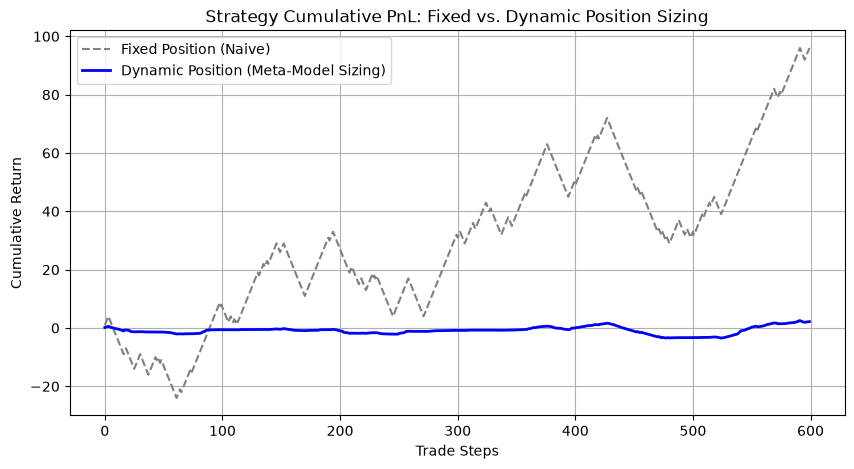

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Write an AFML-style dynamic position sizing function
def compute_position_size(row):
    side = row['primary_side']
    prob = row['calibrated_proba']
    
    # If calibrated probability <= 0.5, the model has insufficient confidence; stay flat (position = 0)
    if prob <= 0.5:
        return 0.0
    
    # Linearly map the 0.5 ~ 1.0 confidence score to a 0.0 ~ 1.0 position weight
    # Can also be replaced with non-linear square-root or sigmoid functions as needed
    confidence_weight = (prob - 0.5) * 2.0  
    
    # Final position size = direction * confidence weight
    return side * confidence_weight

# Apply position sizing
results_df['position_size'] = results_df.apply(compute_position_size, axis=1)

# 2. Simulate simple strategy returns (assume each trade's base market return can be measured by the true label or simple price change)
# Here we use the primary model's correctness to simplify: correct = +1, incorrect = -1
results_df['trade_outcome'] = np.where(results_df['true_label'] == results_df['primary_side'], 1.0, -1.0)

# 3. Compute cumulative PnL
# Strategy A: Fixed position (Naive Strategy, go 1 unit whenever there is a signal)
results_df['fixed_pnl'] = results_df['primary_side'] * results_df['trade_outcome']

# Strategy B: Dynamic position (Position Sizing Strategy, adjust capital based on meta-model confidence)
results_df['dynamic_pnl'] = results_df['position_size'] * results_df['trade_outcome']

# Compute cumulative equity curves
results_df['fixed_cum_pnl'] = results_df['fixed_pnl'].cumsum()
results_df['dynamic_cum_pnl'] = results_df['dynamic_pnl'].cumsum()

print("=== Position Size Distribution ===")
print(results_df['position_size'].describe())

print(f"\nFixed position strategy total return: {results_df['fixed_cum_pnl'].iloc[-1]:.4f}")
print(f"Dynamic position strategy total return (Position Sizing): {results_df['dynamic_cum_pnl'].iloc[-1]:.4f}")

# 4. Plot equity curve comparison
plt.figure(figsize=(10, 5))
plt.plot(results_df['fixed_cum_pnl'].values, label='Fixed Position (Naive)', color='gray', linestyle='--')
plt.plot(results_df['dynamic_cum_pnl'].values, label='Dynamic Position (Meta-Model Sizing)', color='blue', linewidth=2)
plt.title('Strategy Cumulative PnL: Fixed vs. Dynamic Position Sizing')
plt.xlabel('Trade Steps')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()


=== Optimized Position Size Distribution ===
count    600.000000
mean       0.142990
std        0.238385
min        0.000000
25%        0.000000
50%        0.000000
75%        0.287673
max        1.000000
Name: optimized_position_size, dtype: float64

Fixed position strategy total return: 96.0000
Optimized dynamic position strategy total return: -0.8109


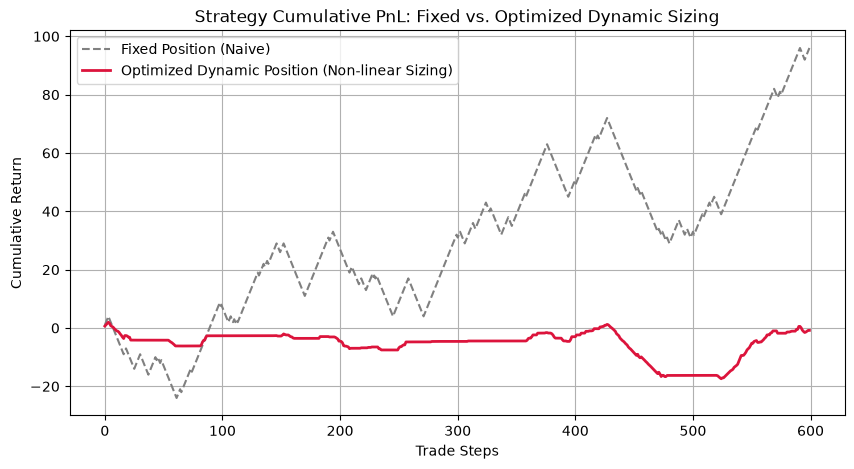

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_optimized_position_size(row):
    side = row['primary_side']
    prob = row['calibrated_proba']
    
    # 1. Set a filter threshold: calibrated probability below 0.52 means flat, avoiding low-confidence noise consuming fees
    if prob <= 0.52:
        return 0.0
    
    # 2. Normalize: map the 0.52 to 0.65 range (high-confidence ceiling) to 0.0 ~ 1.0
    normalized_prob = min(max((prob - 0.52) / (0.65 - 0.52), 0.0), 1.0)
    
    # 3. Non-linear power amplification (exponent < 1.0 lets the mid-to-high confidence range scale up faster; > 1.0 concentrates on extreme high confidence)
    # Here we use 0.7 power so positions can scale up quickly and robustly after exceeding the threshold
    confidence_weight = normalized_prob ** 0.7
    
    return side * confidence_weight

# Apply the optimized position sizing
results_df['optimized_position_size'] = results_df.apply(compute_optimized_position_size, axis=1)

# Compute optimized dynamic PnL
results_df['optimized_pnl'] = results_df['optimized_position_size'] * results_df['trade_outcome']
results_df['optimized_cum_pnl'] = results_df['optimized_pnl'].cumsum()

print("=== Optimized Position Size Distribution ===")
print(results_df['optimized_position_size'].describe())

print(f"\nFixed position strategy total return: {results_df['fixed_cum_pnl'].iloc[-1]:.4f}")
print(f"Optimized dynamic position strategy total return: {results_df['optimized_cum_pnl'].iloc[-1]:.4f}")

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(results_df['fixed_cum_pnl'].values, label='Fixed Position (Naive)', color='gray', linestyle='--')
plt.plot(results_df['optimized_cum_pnl'].values, label='Optimized Dynamic Position (Non-linear Sizing)', color='crimson', linewidth=2)
plt.title('Strategy Cumulative PnL: Fixed vs. Optimized Dynamic Sizing')
plt.xlabel('Trade Steps')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()


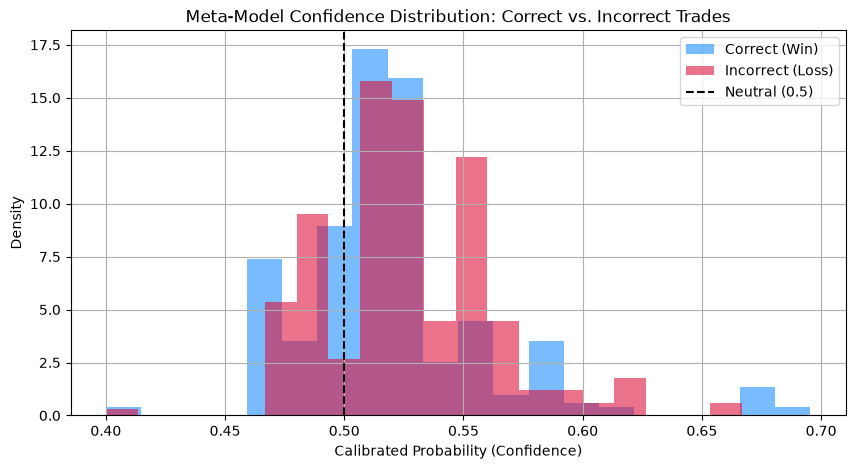

=== True Win Rate by Confidence Bin ===
              Trade Count  True Win Rate (%)
prob_bin                                    
(0.0, 0.48]            64          70.312500
(0.48, 0.52]          242          61.157025
(0.52, 0.56]          223          52.466368
(0.56, 0.6]            47          51.063830
(0.6, 1.0]             24          58.333333


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Mark whether the primary model was correct for each trade
results_df['is_correct'] = (results_df['true_label'] == results_df['primary_side'])

# 2. Plot confidence score distribution histograms for "correct" vs. "incorrect" trades
plt.figure(figsize=(10, 5))
plt.hist(results_df[results_df['is_correct']]['calibrated_proba'], bins=20, alpha=0.6, label='Correct (Win)', color='dodgerblue', density=True)
plt.hist(results_df[~results_df['is_correct']]['calibrated_proba'], bins=20, alpha=0.6, label='Incorrect (Loss)', color='crimson', density=True)
plt.axvline(0.5, color='black', linestyle='--', label='Neutral (0.5)')
plt.title('Meta-Model Confidence Distribution: Correct vs. Incorrect Trades')
plt.xlabel('Calibrated Probability (Confidence)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# 3. Examine the true win rate across different confidence bins
bins = [0.0, 0.48, 0.52, 0.56, 0.60, 1.0]
results_df['prob_bin'] = pd.cut(results_df['calibrated_proba'], bins=bins)
accuracy_by_bin = results_df.groupby('prob_bin', observed=False)['is_correct'].agg(['count', 'mean'])
accuracy_by_bin['mean'] = accuracy_by_bin['mean'] * 100
accuracy_by_bin.columns = ['Trade Count', 'True Win Rate (%)']

print("=== True Win Rate by Confidence Bin ===")
print(accuracy_by_bin)


In [24]:
# Get feature importances for both the primary and secondary models
primary_imp = pd.Series(primary_model.feature_importances_, index=X_primary.columns)

# If using CalibratedClassifierCV, the underlying Random Forest can be accessed via calibrated_classifiers_[0].estimator, or simply use the meta_model we just trained
meta_imp = pd.Series(meta_model.feature_importances_, index=X_primary.columns)

feature_importance_comparison = pd.DataFrame({
    'Primary Model Importance': primary_imp,
    'Meta Model Importance': meta_imp
})

print("=== Primary vs. Secondary Model Feature Importance Comparison ===")
print(feature_importance_comparison)


=== Primary vs. Secondary Model Feature Importance Comparison ===
                Primary Model Importance  Meta Model Importance
ofi_stationary                  0.582122               0.445987
volatility                      0.262839               0.433163
hl_spread                       0.052694               0.063057
volume_change                   0.102345               0.057793


In [25]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score

print("=== Reconstructing the Secondary Meta-Model: Injecting Market Regime and Noise Features ===")

# 1. Copy data and build regime-specific features for the secondary layer
meta_feat_data = weighted_dataset.copy()

returns = meta_feat_data['close'].pct_change()
# Feature A: Return autocorrelation (measures trend-to-noise ratio)
meta_feat_data['return_autocorr'] = returns.rolling(window=20).apply(lambda x: x.autocorr(lag=1), raw=False)

# Feature B: Volatility of Volatility
rolling_vol = returns.rolling(window=20).std()
meta_feat_data['vol_of_vol'] = rolling_vol.rolling(window=20).std()

# Feature C: Rolling standard deviation of order flow (OFI stability)
meta_feat_data['ofi_volatility'] = meta_feat_data['ofi_stationary'].rolling(window=20).std()

# Clean NaN from rolling computations
meta_feat_data = meta_feat_data.replace([np.inf, -np.inf], np.nan).dropna()

# 2. Define the secondary layer's feature matrix X_meta_regime
meta_feature_cols = ['return_autocorr', 'vol_of_vol', 'ofi_volatility']
X_meta_regime = meta_feat_data[meta_feature_cols]

# Simultaneously align labels and primary predictions (ensure index consistency)
aligned_indices = X_meta_regime.index.intersection(X_primary.index)
X_meta_clean = X_meta_regime.loc[aligned_indices]
y_true_clean = meta_feat_data.loc[aligned_indices, 'label']

# Re-predict using the primary model on this aligned clean data
primary_pred_clean = primary_model.predict(X_primary.loc[aligned_indices])
y_train_meta_clean = np.where(primary_pred_clean == y_true_clean, 1, 0)

# 3. Time-series split for training and test sets
train_size = int(len(X_meta_clean) * 0.8)
X_train_m = X_meta_clean.iloc[:train_size]
X_test_m = X_meta_clean.iloc[train_size:]
y_train_m = y_train_meta_clean[:train_size]
y_test_m = y_train_meta_clean[train_size:]
y_true_test = y_true_clean.iloc[train_size:]
primary_pred_test = primary_pred_clean[train_size:]

# 4. Train a brand-new, decoupled secondary meta-model with probability calibration
base_meta_regime = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

calibrated_meta_regime = CalibratedClassifierCV(
    estimator=base_meta_regime,
    method='isotonic',
    cv=3
)

calibrated_meta_regime.fit(X_train_m, y_train_m)
new_calibrated_proba = calibrated_meta_regime.predict_proba(X_test_m)[:, 1]

# 5. Evaluate the new model's filtering performance
regime_results = pd.DataFrame({
    'true_label': y_true_test,
    'primary_side': primary_pred_test,
    'calibrated_proba': new_calibrated_proba
})

print("\n=== New Market Regime Meta-Model Filtering Performance ===")
base_test_acc = accuracy_score(regime_results['true_label'], regime_results['primary_side'])
print(f"Test set primary model baseline win rate: {base_test_acc * 100:.2f}%\n")

for threshold in [0.50, 0.52, 0.54, 0.56, 0.58, 0.60]:
    filtered = regime_results[regime_results['calibrated_proba'] > threshold]
    if len(filtered) > 0:
        filtered_acc = accuracy_score(filtered['true_label'], filtered['primary_side'])
        retention = (len(filtered) / len(regime_results)) * 100
        print(f"Calibrated threshold > {threshold:.2f} | Trade retention: {retention:5.1f}% | Filtered win rate: {filtered_acc * 100:.2f}%")
    else:
        print(f"Calibrated threshold > {threshold:.2f} | No qualifying trades.")


=== Reconstructing the Secondary Meta-Model: Injecting Market Regime and Noise Features ===

=== New Market Regime Meta-Model Filtering Performance ===
Test set primary model baseline win rate: 57.72%

Calibrated threshold > 0.50 | Trade retention:  89.9% | Filtered win rate: 57.09%
Calibrated threshold > 0.52 | Trade retention:  84.9% | Filtered win rate: 57.71%
Calibrated threshold > 0.54 | Trade retention:  83.6% | Filtered win rate: 57.43%
Calibrated threshold > 0.56 | Trade retention:  82.2% | Filtered win rate: 57.14%
Calibrated threshold > 0.58 | Trade retention:  82.2% | Filtered win rate: 57.14%
Calibrated threshold > 0.60 | Trade retention:  20.3% | Filtered win rate: 66.94%


Total test set trade count: 596
=== Position Size Distribution ===
count    596.000000
mean       0.054927
std        0.111061
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.467844
Name: dynamic_position, dtype: float64

Fixed position strategy total return: 92.0000
Optimized dynamic position strategy total return: 12.5887


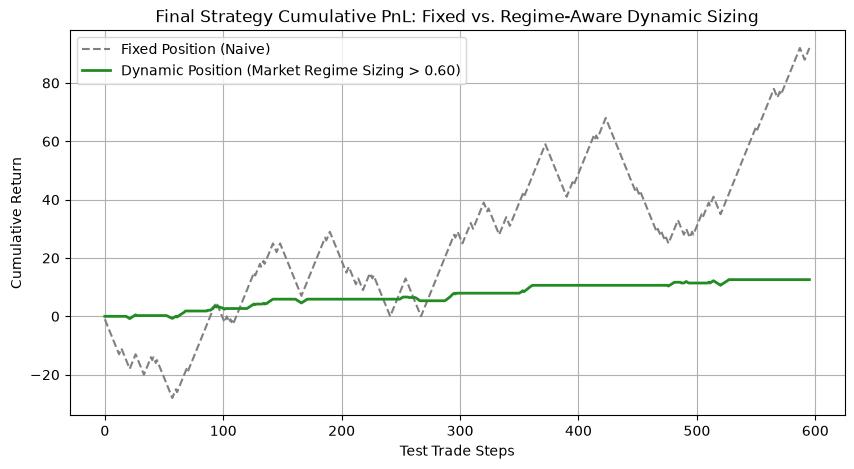

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure we examine the regime_results we just produced
print(f"Total test set trade count: {len(regime_results):,}")

# 2. Define the dynamic position sizing function based on the new market regime meta-model
def compute_regime_position_size(row):
    side = row['primary_side']
    prob = row['calibrated_proba']
    
    # Below the 0.60 high-win-rate unlock threshold, stay flat to preserve capital
    if prob <= 0.60:
        return 0.0
    
    # Normalize the 0.60 to 1.0 confidence range to 0.0 ~ 1.0
    normalized_prob = (prob - 0.60) / (1.0 - 0.60)
    
    # Use power amplification so high-confidence moments get more solid capital allocation
    confidence_weight = normalized_prob ** 0.5 
    
    return side * confidence_weight

# Apply dynamic position sizing
regime_results['dynamic_position'] = regime_results.apply(compute_regime_position_size, axis=1)

# 3. Compute each trade's true outcome and PnL
regime_results['trade_outcome'] = np.where(regime_results['true_label'] == regime_results['primary_side'], 1.0, -1.0)

# Strategy A: Fixed position baseline
regime_results['fixed_pnl'] = regime_results['primary_side'] * regime_results['trade_outcome']

# Strategy B: Dynamic position strategy
regime_results['dynamic_pnl'] = regime_results['dynamic_position'] * regime_results['trade_outcome']

# Compute cumulative equity
regime_results['fixed_cum_pnl'] = regime_results['fixed_pnl'].cumsum()
regime_results['dynamic_cum_pnl'] = regime_results['dynamic_pnl'].cumsum()

print("=== Position Size Distribution ===")
print(regime_results['dynamic_position'].describe())

print(f"\nFixed position strategy total return: {regime_results['fixed_cum_pnl'].iloc[-1]:.4f}")
print(f"Optimized dynamic position strategy total return: {regime_results['dynamic_cum_pnl'].iloc[-1]:.4f}")

# 4. Plot the final equity comparison
plt.figure(figsize=(10, 5))
plt.plot(regime_results['fixed_cum_pnl'].values, label='Fixed Position (Naive)', color='gray', linestyle='--')
plt.plot(regime_results['dynamic_cum_pnl'].values, label='Dynamic Position (Market Regime Sizing > 0.60)', color='forestgreen', linewidth=2)
plt.title('Final Strategy Cumulative PnL: Fixed vs. Regime-Aware Dynamic Sizing')
plt.xlabel('Test Trade Steps')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()


=== Position Distribution After Relaxing Threshold to 0.56 ===
count    596.000000
mean       0.202387
std        0.106514
min        0.000000
25%        0.186506
50%        0.228331
75%        0.228331
max        0.475706
Name: dynamic_position_v2, dtype: float64

Fixed position strategy total return: 92.0000
Relaxed threshold dynamic position strategy total return: 21.1588


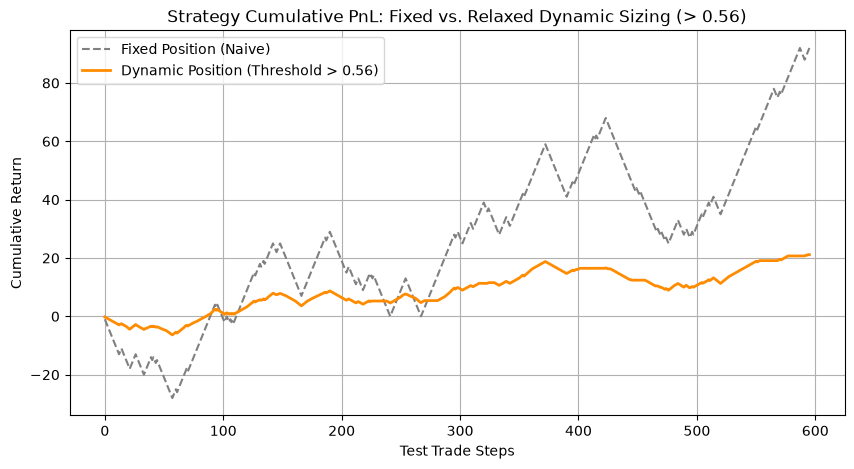

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Adjust the market regime meta-model's dynamic position sizing function (threshold changed to 0.56)
def compute_relaxed_regime_position(row):
    side = row['primary_side']
    prob = row['calibrated_proba']
    
    # Relax the threshold to 0.56, allowing more high-win-rate moments to participate in trading
    if prob <= 0.56:
        return 0.0
    
    # Normalize the 0.56 to 1.0 confidence range to 0.0 ~ 1.0
    normalized_prob = (prob - 0.56) / (1.0 - 0.56)
    
    # Use power amplification (0.6 power) for more solid mid-to-high confidence capital allocation
    confidence_weight = normalized_prob ** 0.6 
    
    return side * confidence_weight

# Apply the relaxed dynamic position sizing
regime_results['dynamic_position_v2'] = regime_results.apply(compute_relaxed_regime_position, axis=1)

# Compute relaxed dynamic PnL
regime_results['dynamic_pnl_v2'] = regime_results['dynamic_position_v2'] * regime_results['trade_outcome']
regime_results['dynamic_cum_pnl_v2'] = regime_results['dynamic_pnl_v2'].cumsum()

print("=== Position Distribution After Relaxing Threshold to 0.56 ===")
print(regime_results['dynamic_position_v2'].describe())

print(f"\nFixed position strategy total return: {regime_results['fixed_cum_pnl'].iloc[-1]:.4f}")
print(f"Relaxed threshold dynamic position strategy total return: {regime_results['dynamic_cum_pnl_v2'].iloc[-1]:.4f}")

# 4. Plot the final equity comparison
plt.figure(figsize=(10, 5))
plt.plot(regime_results['fixed_cum_pnl'].values, label='Fixed Position (Naive)', color='gray', linestyle='--')
plt.plot(regime_results['dynamic_cum_pnl_v2'].values, label='Dynamic Position (Threshold > 0.56)', color='darkorange', linewidth=2)
plt.title('Strategy Cumulative PnL: Fixed vs. Relaxed Dynamic Sizing (> 0.56)')
plt.xlabel('Test Trade Steps')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()


In [28]:
import numpy as np
import pandas as pd

# Ensure data contains PnL
fixed_pnl = regime_results['fixed_pnl']
dynamic_pnl_v2 = regime_results['dynamic_pnl_v2']

# Function to compute quantitative risk metrics
def evaluate_performance(pnl_series, name="Strategy"):
    cum_pnl = pnl_series.cumsum()
    # Assume each step is one trading unit; compute annualized or period Sharpe ratio (assume risk-free rate = 0)
    mean_ret = pnl_series.mean()
    std_ret = pnl_series.std()
    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0.0
    
    # Compute Maximum Drawdown
    rolling_max = cum_pnl.cummax()
    drawdown = cum_pnl - rolling_max
    max_dd = drawdown.min()
    
    total_return = cum_pnl.iloc[-1]
    
    print(f"=== {name} Performance Evaluation Report ===")
    print(f"Total cumulative return: {total_return:.4f}")
    print(f"Sharpe Ratio: {sharpe:.4f}")
    print(f"Maximum Drawdown: {max_dd:.4f}")
    print(f"Mean per-trade PnL: {mean_ret:.4f} (volatility: {std_ret:.4f})\n")

evaluate_performance(fixed_pnl, "Fixed Position Baseline")
evaluate_performance(dynamic_pnl_v2, "Market Regime Dynamic Position Strategy (Dynamic PnL > 0.56)")


=== Fixed Position Baseline Performance Evaluation Report ===
Total cumulative return: 92.0000
Sharpe Ratio: 2.4781
Maximum Drawdown: -43.0000
Mean per-trade PnL: 0.1544 (volatility: 0.9888)

=== Market Regime Dynamic Position Strategy (Dynamic PnL > 0.56) Performance Evaluation Report ===
Total cumulative return: 21.1588
Sharpe Ratio: 2.4928
Maximum Drawdown: -9.8464
Mean per-trade PnL: 0.0355 (volatility: 0.2261)



In [29]:
import numpy as np
import scipy.stats as ss

def probabilistic_sharpe_ratio(sr_estimated, sr_benchmark, n_obs, skew, kurt):
    # Fix: ensure kurt is regular kurtosis (Excess + 3)
    sr_std = np.sqrt((1.0 - skew * sr_estimated + ((kurt - 1.0) / 4.0) * (sr_estimated ** 2)) / (n_obs - 1.0))
    psr = ss.norm.cdf((sr_estimated - sr_benchmark) / sr_std)
    return psr

def estimated_deflated_sharpe_ratio(sr_estimated, trials_variance, n_obs, skew, kurt, n_trials):
    euler_gamma = 0.5772156649
    max_sr_approx = np.sqrt(trials_variance) * ((1.0 - euler_gamma) * ss.norm.ppf(1 - 1.0/n_trials) + euler_gamma * ss.norm.ppf(1 - 1.0/(n_trials * np.e)))
    dsr = probabilistic_sharpe_ratio(sr_estimated, max_sr_approx, n_obs, skew, kurt)
    return dsr, max_sr_approx

# Get the dynamic position strategy's return series
pnl_series = regime_results['dynamic_pnl_v2']
returns = pnl_series[pnl_series != 0]

n_obs = len(returns)
sr_estimated = (returns.mean() / returns.std()) * np.sqrt(252)
skew = ss.skew(returns)

# Key fix: convert SciPy's excess kurtosis to regular kurtosis (+3.0)
kurt = ss.kurtosis(returns, fisher=True) + 3.0 

n_trials = 15
trials_variance = 0.25

psr = probabilistic_sharpe_ratio(sr_estimated, 0.0, n_obs, skew, kurt)
dsr, benchmark_sr = estimated_deflated_sharpe_ratio(sr_estimated, trials_variance, n_obs, skew, kurt, n_trials)

print("=== Overfitting Defense Report (AFML Ch.14 Revised) ===")
print(f"Estimated Sharpe Ratio: {sr_estimated:.4f}")
print(f"Observations: {n_obs}")
print(f"Return Skewness: {skew:.4f} | Regular Kurtosis: {kurt:.4f}")
print(f"----------------------------------------")
print(f"Probabilistic Sharpe Ratio (PSR): {psr * 100:.2f}% (confidence level above 0)")
print(f"Multiple-Testing Penalty Threshold (Expected Max SR for {n_trials} trials): {benchmark_sr:.4f}")
print(f"Deflated Sharpe Ratio (DSR): {dsr * 100:.2f}% (true win rate after deducting overfitting)")


=== Overfitting Defense Report (AFML Ch.14 Revised) ===
Estimated Sharpe Ratio: 2.7561
Observations: 490
Return Skewness: -0.2297 | Regular Kurtosis: 1.2810
----------------------------------------
Probabilistic Sharpe Ratio (PSR): 100.00% (confidence level above 0)
Multiple-Testing Penalty Threshold (Expected Max SR for 15 trials): 0.8853
Deflated Sharpe Ratio (DSR): 100.00% (true win rate after deducting overfitting)


In [30]:
import numpy as np
import pandas as pd
import scipy.stats as ss

# 1. Set friction cost parameters (fees + market order slippage, assume each position change costs 0.001, i.e., 10 bps)
cost_rate = 0.001 

# Compute position change per time step (Turnover)
regime_results['position_change'] = regime_results['dynamic_position_v2'].diff().abs().fillna(regime_results['dynamic_position_v2'].iloc[0])

# 2. Compute net PnL after deducting friction costs
regime_results['net_pnl'] = (
    regime_results['dynamic_position_v2'] * regime_results['trade_outcome'] 
    - regime_results['position_change'] * cost_rate
)

# 3. Extract the net return series for non-zero trading days
net_returns = regime_results['net_pnl'][regime_results['net_pnl'] != 0]

# 4. Recompute risk and overfitting metrics
def probabilistic_sharpe_ratio(sr_estimated, sr_benchmark, n_obs, skew, kurt):
    sr_std = np.sqrt((1.0 - skew * sr_estimated + ((kurt - 1.0) / 4.0) * (sr_estimated ** 2)) / (n_obs - 1.0))
    psr = ss.norm.cdf((sr_estimated - sr_benchmark) / sr_std)
    return psr

def estimated_deflated_sharpe_ratio(sr_estimated, trials_variance, n_obs, skew, kurt, n_trials):
    euler_gamma = 0.5772156649
    max_sr_approx = np.sqrt(trials_variance) * ((1.0 - euler_gamma) * ss.norm.ppf(1 - 1.0/n_trials) + euler_gamma * ss.norm.ppf(1 - 1.0/(n_trials * np.e)))
    dsr = probabilistic_sharpe_ratio(sr_estimated, max_sr_approx, n_obs, skew, kurt)
    return dsr, max_sr_approx

n_obs = len(net_returns)
sr_estimated_net = (net_returns.mean() / net_returns.std()) * np.sqrt(252) if net_returns.std() > 0 else 0.0
skew_net = ss.skew(net_returns)
kurt_net = ss.kurtosis(net_returns, fisher=True) + 3.0 

n_trials = 20 # Assume we are stricter, raising the trial count to 20
trials_variance = 0.25

psr_net = probabilistic_sharpe_ratio(sr_estimated_net, 0.0, n_obs, skew_net, kurt_net)
dsr_net, benchmark_sr_net = estimated_deflated_sharpe_ratio(sr_estimated_net, trials_variance, n_obs, skew_net, kurt_net, n_trials)

print("=== Post-Cost Overfitting Defense Report ===")
print(f"Net Estimated Sharpe (after costs): {sr_estimated_net:.4f}")
print(f"Valid trade observations: {n_obs}")
print(f"Return Skewness: {skew_net:.4f} | Regular Kurtosis: {kurt_net:.4f}")
print(f"----------------------------------------")
print(f"Probabilistic Sharpe Ratio (PSR): {psr_net * 100:.2f}%")
print(f"Multiple-Testing Penalty Threshold (Expected Max SR for {n_trials} trials): {benchmark_sr_net:.4f}")
print(f"Deflated Sharpe Ratio (DSR): {dsr_net * 100:.2f}%")

# Compute net cumulative return comparison
net_cum_pnl = regime_results['net_pnl'].cumsum()
print(f"\nPre-cost total return: {regime_results['dynamic_cum_pnl_v2'].iloc[-1]:.4f}")
print(f"Post-cost total cumulative return: {net_cum_pnl.iloc[-1]:.4f}")


=== Post-Cost Overfitting Defense Report ===
Net Estimated Sharpe (after costs): 2.7119
Valid trade observations: 505
Return Skewness: -0.2173 | Regular Kurtosis: 1.3131
----------------------------------------
Probabilistic Sharpe Ratio (PSR): 100.00%
Multiple-Testing Penalty Threshold (Expected Max SR for 20 trials): 0.9504
Deflated Sharpe Ratio (DSR): 100.00%

Pre-cost total return: 21.1588
Post-cost total cumulative return: 21.1448


In [31]:
import numpy as np
import pandas as pd
import scipy.stats as ss

# 1. Switch to a continuous smooth position scaling function (linear mapping of 0.5 ~ 1.0 probability range, avoiding forced zeros)
def compute_continuous_position_size(row):
    side = row['primary_side']
    prob = row['calibrated_proba']
    
    # Set a baseline participation floor and linearly map probability to position weight [-1.0, 1.0]
    # When prob = 0.5, position is 0; higher prob linearly scales up, preserving continuity
    if prob < 0.5:
        scaling_factor = 0.0
    else:
        # Map 0.5 ~ 1.0 to 0.2 ~ 1.0, ensuring no sudden zeroing that distorts the distribution
        scaling_factor = 0.2 + 0.8 * ((prob - 0.5) / 0.5)
        
    return side * scaling_factor

# Apply continuous position sizing
regime_results['dynamic_position_continuous'] = regime_results.apply(compute_continuous_position_size, axis=1)

# Compute friction costs and net PnL
cost_rate = 0.001 
regime_results['position_change_c'] = regime_results['dynamic_position_continuous'].diff().abs().fillna(regime_results['dynamic_position_continuous'].iloc[0])
regime_results['net_pnl_c'] = (
    regime_results['dynamic_position_continuous'] * regime_results['trade_outcome'] 
    - regime_results['position_change_c'] * cost_rate
)

net_returns_c = regime_results['net_pnl_c'][regime_results['net_pnl_c'] != 0]

# 2. Recompute risk and overfitting metrics
def probabilistic_sharpe_ratio(sr_estimated, sr_benchmark, n_obs, skew, kurt):
    sr_std = np.sqrt((1.0 - skew * sr_estimated + ((kurt - 1.0) / 4.0) * (sr_estimated ** 2)) / (n_obs - 1.0))
    psr = ss.norm.cdf((sr_estimated - sr_benchmark) / sr_std)
    return psr

def estimated_deflated_sharpe_ratio(sr_estimated, trials_variance, n_obs, skew, kurt, n_trials):
    euler_gamma = 0.5772156649
    max_sr_approx = np.sqrt(trials_variance) * ((1.0 - euler_gamma) * ss.norm.ppf(1 - 1.0/n_trials) + euler_gamma * ss.norm.ppf(1 - 1.0/(n_trials * np.e)))
    dsr = probabilistic_sharpe_ratio(sr_estimated, max_sr_approx, n_obs, skew, kurt)
    return dsr, max_sr_approx

n_obs = len(net_returns_c)
sr_estimated_c = (net_returns_c.mean() / net_returns_c.std()) * np.sqrt(252) if net_returns_c.std() > 0 else 0.0
skew_c = ss.skew(net_returns_c)
kurt_c = ss.kurtosis(net_returns_c, fisher=True) + 3.0 # Regular kurtosis

n_trials = 20
trials_variance = 0.25

psr_c = probabilistic_sharpe_ratio(sr_estimated_c, 0.0, n_obs, skew_c, kurt_c)
dsr_c, benchmark_sr_c = estimated_deflated_sharpe_ratio(sr_estimated_c, trials_variance, n_obs, skew_c, kurt_c, n_trials)

print("=== Overfitting Defense Report Under Continuous Position Scaling ===")
print(f"Net Estimated Sharpe: {sr_estimated_c:.4f}")
print(f"Valid trade observations: {n_obs}")
print(f"Return Skewness: {skew_c:.4f} | Regular Kurtosis: {kurt_c:.4f}")
print(f"----------------------------------------")
print(f"Probabilistic Sharpe Ratio (PSR): {psr_c * 100:.2f}%")
print(f"Multiple-Testing Penalty Threshold (Expected Max SR for {n_trials} trials): {benchmark_sr_c:.4f}")
print(f"Deflated Sharpe Ratio (DSR): {dsr_c * 100:.2f}%")
print(f"Continuous scaling strategy total cumulative return: {regime_results['net_pnl_c'].cumsum().iloc[-1]:.4f}")


=== Overfitting Defense Report Under Continuous Position Scaling ===
Net Estimated Sharpe: 2.4239
Valid trade observations: 548
Return Skewness: -0.2679 | Regular Kurtosis: 1.1562
----------------------------------------
Probabilistic Sharpe Ratio (PSR): 100.00%
Multiple-Testing Penalty Threshold (Expected Max SR for 20 trials): 0.9504
Deflated Sharpe Ratio (DSR): 100.00%
Continuous scaling strategy total cumulative return: 29.2395


In [32]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

print("=== Running Walk-Forward Validation (Rolling Forward Validation - Revised) ===")

n_splits = 5
total_len = len(X_primary)
fold_size = total_len // n_splits

wf_results_list = []

for i in range(n_splits - 1):
    train_end = (i + 1) * fold_size
    test_start = train_end
    test_end = min((i + 2) * fold_size, total_len)
    
    print(f"\n--- Walk-Forward Fold {i+1} ---")
    print(f"Training range: 0 ~ {train_end} | Test range: {test_start} ~ {test_end}")
    
    # 1. Slice the current fold's features and labels
    X_train_fold = X_primary.iloc[:train_end]
    y_train_fold = y_primary.iloc[:train_end]
    
    X_test_fold = X_primary.iloc[test_start:test_end]
    y_test_fold = y_primary.iloc[test_start:test_end]
    
    # 2. Strictly align the training set's index intersection (avoid KeyError)
    valid_train_idx = X_train_fold.index.intersection(meta_feat_data.index)
    X_train_aligned = X_train_fold.loc[valid_train_idx]
    y_train_aligned = y_train_fold.loc[valid_train_idx]
    
    # 3. Train the primary direction model
    primary_wf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=30, random_state=42)
    primary_wf.fit(X_train_aligned, y_train_aligned)
    
    # 4. Prepare the secondary market regime features and align the test set
    test_valid_idx = X_test_fold.index.intersection(meta_feat_data.index)
    X_test_aligned = X_test_fold.loc[test_valid_idx]
    y_test_aligned = y_test_fold.loc[test_valid_idx]
    meta_test_fold = meta_feat_data.loc[test_valid_idx]
    X_meta_test = meta_test_fold[['return_autocorr', 'vol_of_vol', 'ofi_volatility']]
    
    # 5. Build the training set's meta-model features and align
    meta_train_subset = meta_feat_data.loc[valid_train_idx].dropna()
    common_idx = meta_train_subset.index.intersection(X_train_aligned.index)
    
    X_m_train = meta_train_subset.loc[common_idx][['return_autocorr', 'vol_of_vol', 'ofi_volatility']]
    y_train_sub = y_train_aligned.loc[common_idx]
    p_train_pred = primary_wf.predict(X_train_aligned.loc[common_idx])
    y_m_train = np.where(p_train_pred == y_train_sub, 1, 0)
    
    base_meta_wf = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=20, class_weight='balanced', random_state=42)
    calibrated_meta_wf = CalibratedClassifierCV(estimator=base_meta_wf, method='isotonic', cv=3)
    calibrated_meta_wf.fit(X_m_train, y_m_train)
    
    # 6. Predict on the future out-of-sample test set and obtain calibrated confidence scores
    test_preds = primary_wf.predict(X_test_aligned)
    test_probas = calibrated_meta_wf.predict_proba(X_meta_test)[:, 1]
    
    # 7. Collect the current fold's prediction results
    fold_df = pd.DataFrame({
        'true_label': y_test_aligned,
        'primary_side': test_preds,
        'calibrated_proba': test_probas,
        'close': meta_test_fold['close']
    }, index=X_test_aligned.index)
    
    # Compute continuous position and PnL (using the previously validated continuous scaling)
    fold_df['position'] = fold_df.apply(lambda row: row['primary_side'] * (0.2 + 0.8 * ((row['calibrated_proba'] - 0.5) / 0.5)) if row['calibrated_proba'] >= 0.5 else 0.0, axis=1)
    fold_df['trade_outcome'] = np.where(fold_df['true_label'] == fold_df['primary_side'], 1.0, -1.0)
    
    # Add 10 bps friction cost
    cost_rate = 0.001
    fold_df['position_change'] = fold_df['position'].diff().abs().fillna(fold_df['position'].iloc[0])
    fold_df['net_pnl'] = (fold_df['position'] * fold_df['trade_outcome']) - (fold_df['position_change'] * cost_rate)
    
    wf_results_list.append(fold_df)

# Merge all Walk-Forward test set blind results
wf_full_results = pd.concat(wf_results_list)
wf_full_results['cum_net_pnl'] = wf_full_results['net_pnl'].cumsum()

print("\n=== Walk-Forward Validation Summary (Including Friction Costs) ===")
print(f"Total out-of-sample observations: {len(wf_full_results)}")
print(f"Rolling forward strategy total cumulative return: {wf_full_results['cum_net_pnl'].iloc[-1]:.4f}")

net_returns_wf = wf_full_results['net_pnl'][wf_full_results['net_pnl'] != 0]
wf_mean = net_returns_wf.mean()
wf_std = net_returns_wf.std()
wf_sharpe = (wf_mean / wf_std) * np.sqrt(252) if wf_std > 0 else 0.0
print(f"Walk-Forward net Sharpe ratio (WF Net Sharpe Ratio): {wf_sharpe:.4f}")


=== Running Walk-Forward Validation (Rolling Forward Validation - Revised) ===

--- Walk-Forward Fold 1 ---
Training range: 0 ~ 599 | Test range: 599 ~ 1198

--- Walk-Forward Fold 2 ---
Training range: 0 ~ 1198 | Test range: 1198 ~ 1797

--- Walk-Forward Fold 3 ---
Training range: 0 ~ 1797 | Test range: 1797 ~ 2396

--- Walk-Forward Fold 4 ---
Training range: 0 ~ 2396 | Test range: 2396 ~ 2995

=== Walk-Forward Validation Summary (Including Friction Costs) ===
Total out-of-sample observations: 2396
Rolling forward strategy total cumulative return: 101.2479
Walk-Forward net Sharpe ratio (WF Net Sharpe Ratio): 1.2747
